# Notebook 2b: 短窗口运动分类器

使用 2s 短窗口特征训练 RF 分类器, 对波比跳窗口推理后聚合回 8s 粒度。

**关键改进**: 窗口匹配物理过程 → 特征更纯净 → 预测分布更均衡。

**输出产物**: `artifacts/burpee_window_distributions_shortwin.npy` (8s 聚合后)

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pickle
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize

PROJECT_ROOT = Path(r"D:\data\PPG_HeartRate\Algorithm\outline-PPGtoHR")
ARTIFACTS_DIR = PROJECT_ROOT / "docs" / "research" / "artifacts"

sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

EXERCISES = {
    "jump_rope":    {"label": "跳绳"},
    "arm_curl":     {"label": "手臂弯举"},
    "push_up":      {"label": "俯卧撑"},
    "jumping_jack": {"label": "开合跳"},
    "burpee":       {"label": "波比跳"},
}

AGG_WIN_SEC = 8.0
AGG_STEP_SEC = 1.0

In [ ]:
with open(ARTIFACTS_DIR / "mimu_features_shortwin.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"]
y = data["y"]
df = data["df"]
FEATURE_NAMES = data["feature_names"]
WIN_SEC = data["win_sec"]
STEP_SEC = data["step_sec"]

print(f"特征矩阵: {X.shape}, 窗口配置: {WIN_SEC}s / {STEP_SEC}s")

simple_mask = df["exercise"].values != "burpee"
burpee_mask = ~simple_mask

X_train_all = X[simple_mask]
y_train_all = y[simple_mask]
files_train_all = df["file_name"].values[simple_mask]

X_burpee = X[burpee_mask]
burpee_times = df["window_time"].values[burpee_mask]
burpee_files = df["file_name"].values[burpee_mask]

print(f"\n训练集 (简单运动): {X_train_all.shape[0]} 个窗口")
print(f"推理集 (波比跳): {X_burpee.shape[0]} 个窗口")
print(f"训练集类别: {dict(zip(*np.unique(y_train_all, return_counts=True)))}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_burpee_scaled = scaler.transform(X_burpee)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_all)
SIMPLE_CLASSES = list(le.classes_)
print(f"\n类别映射: {dict(zip(le.classes_, le.transform(le.classes_)))}")

## 1. 交叉验证 (GroupKFold)

按文件名分组, 避免重叠窗口导致数据泄漏。

In [3]:
groups_train = files_train_all
n_groups = len(np.unique(groups_train))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    class_weight="balanced", random_state=42,
)
rf_scores = cross_val_score(rf, X_train_scaled, y_train_encoded,
                            cv=gkf, groups=groups_train, scoring="accuracy")
print(f"RandomForest GroupKFold({n_splits}): {rf_scores.mean():.3f} +/- {rf_scores.std():.3f}")
print(f"  各折: {[f'{s:.3f}' for s in rf_scores]}")

knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, X_train_scaled, y_train_encoded,
                             cv=gkf, groups=groups_train, scoring="accuracy")
print(f"KNN GroupKFold({n_splits}): {knn_scores.mean():.3f} +/- {knn_scores.std():.3f}")
print(f"  各折: {[f'{s:.3f}' for s in knn_scores]}")

RandomForest GroupKFold(5): 0.765 +/- 0.383
  各折: ['0.937', '0.952', '0.986', '0.951', '0.000']


d:\Anaconda\envs\ppg-hr\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


KNN GroupKFold(5): 0.733 +/- 0.368
  各折: ['0.906', '0.976', '0.883', '0.903', '0.000']


In [ ]:
def cosine_prototype_predict_proba(X_train, y_train, X_test, classes):
    centroids = np.array([X_train[y_train == c].mean(axis=0) for c in range(len(classes))])
    centroids_norm = normalize(centroids)
    X_test_norm = normalize(X_test)
    similarities = X_test_norm @ centroids_norm.T
    exp_sim = np.exp(similarities - similarities.max(axis=1, keepdims=True))
    proba = exp_sim / exp_sim.sum(axis=1, keepdims=True)
    return proba


rf.fit(X_train_scaled, y_train_encoded)
knn.fit(X_train_scaled, y_train_encoded)

rf_proba = rf.predict_proba(X_burpee_scaled)
knn_proba = knn.predict_proba(X_burpee_scaled)
cosine_proba = cosine_prototype_predict_proba(
    X_train_scaled, y_train_encoded, X_burpee_scaled, SIMPLE_CLASSES)

rf_pred = np.array([SIMPLE_CLASSES[i] for i in rf_proba.argmax(axis=1)])
knn_pred = np.array([SIMPLE_CLASSES[i] for i in knn_proba.argmax(axis=1)])
cosine_pred = np.array([SIMPLE_CLASSES[i] for i in cosine_proba.argmax(axis=1)])

print("短窗口分类器在波比跳窗口上的预测分布:")
for name, preds in [("RF", rf_pred), ("KNN", knn_pred), ("Cosine", cosine_pred)]:
    cnt = Counter(preds)
    dist = ", ".join(f"{EXERCISES[k]['label']}: {v}" for k, v in sorted(cnt.items()))
    print(f"  {name}: {dist}")

print(f"\n最大概率统计 (RF): mean={rf_proba.max(axis=1).mean():.3f}, "
      f"min={rf_proba.max(axis=1).min():.3f}, max={rf_proba.max(axis=1).max():.3f}")

RandomForest 训练集分类报告:
              precision    recall  f1-score   support

    arm_curl       1.00      0.97      0.99       246
   jump_rope       1.00      0.98      0.99       227
jumping_jack       0.99      0.99      0.99       248
     push_up       0.81      1.00      0.90        47

    accuracy                           0.98       768
   macro avg       0.95      0.99      0.96       768
weighted avg       0.98      0.98      0.98       768



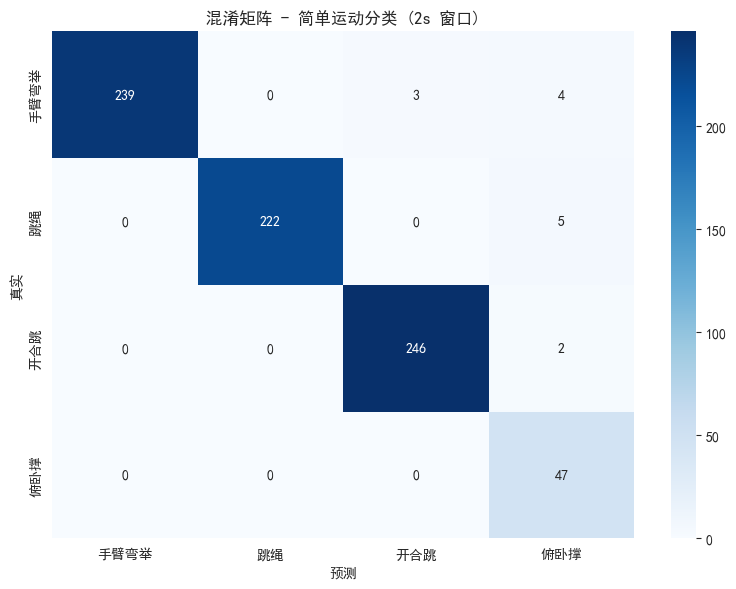

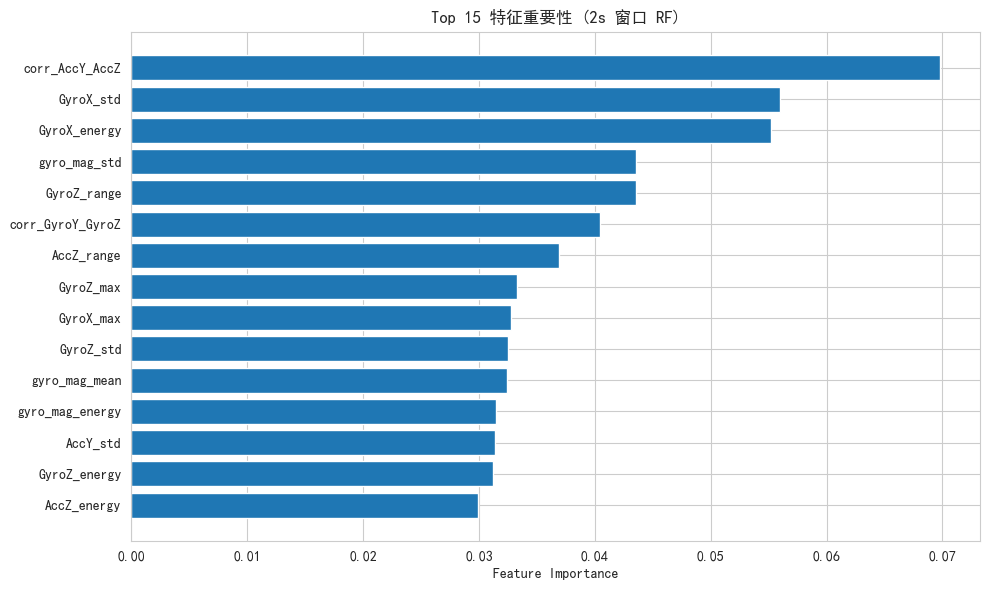

In [5]:
y_pred = rf.predict(X_train_scaled)
print("RandomForest 训练集分类报告:")
print(classification_report(y_train_encoded, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_train_encoded, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[EXERCISES[c]["label"] for c in le.classes_],
            yticklabels=[EXERCISES[c]["label"] for c in le.classes_],
            ax=ax)
ax.set_xlabel("预测")
ax.set_ylabel("真实")
ax.set_title("混淆矩阵 - 简单运动分类 (2s 窗口)")
plt.tight_layout()
plt.show()

importances = rf.feature_importances_
top_k = 15
top_idx = np.argsort(importances)[-top_k:]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_k), importances[top_idx])
ax.set_yticks(range(top_k))
ax.set_yticklabels([FEATURE_NAMES[i] for i in top_idx])
ax.set_xlabel("Feature Importance")
ax.set_title(f"Top {top_k} 特征重要性 (2s 窗口 RF)")
plt.tight_layout()
plt.show()

## 2. 波比跳推理与 8s 聚合

短窗口 (2s) 概率按时间对齐聚合到 8s 窗口, 对下游融合管线透明。
聚合方式: 对每个 8s 锚点 T, 取 [T, T+8s) 内所有短窗口概率的均值。

In [6]:
def aggregate_to_8s(short_times, short_proba, file_names,
                   agg_win_sec=8.0, agg_step_sec=1.0):
    """将短窗口概率聚合到 8s 粒度, 按文件独立处理."""
    all_times, all_proba, all_files, all_counts = [], [], [], []

    for stem in np.unique(file_names):
        stem_mask = file_names == stem
        times_stem = short_times[stem_mask]
        proba_stem = short_proba[stem_mask]

        t_start = times_stem.min()
        t_end = times_stem.max()
        agg_times = np.arange(t_start, t_end - agg_win_sec + agg_step_sec, agg_step_sec)

        for agg_t in agg_times:
            win_mask = (times_stem >= agg_t) & (times_stem < agg_t + agg_win_sec)
            n_short = win_mask.sum()
            if n_short == 0:
                continue
            agg_proba = proba_stem[win_mask].mean(axis=0)
            all_times.append(agg_t)
            all_proba.append(agg_proba)
            all_files.append(stem)
            all_counts.append(n_short)

    return {
        "times": np.array(all_times),
        "proba": np.array(all_proba),
        "files": np.array(all_files),
        "short_counts": np.array(all_counts),
    }


agg_result = aggregate_to_8s(burpee_times, rf_proba, burpee_files)
agg_proba = agg_result["proba"]
agg_times = agg_result["times"]
agg_files = agg_result["files"]

print(f"聚合结果: {agg_proba.shape[0]} 个 8s 窗口 x {agg_proba.shape[1]} 类")
print(f"每个 8s 窗口包含短窗口数: mean={agg_result['short_counts'].mean():.1f}, "
      f"min={agg_result['short_counts'].min()}, max={agg_result['short_counts'].max()}")
print(f"\n聚合后最大概率统计: mean={agg_proba.max(axis=1).mean():.3f}, "
      f"min={agg_proba.max(axis=1).min():.3f}, max={agg_proba.max(axis=1).max():.3f}")

# 聚合后预测分布
agg_pred = np.array([SIMPLE_CLASSES[i] for i in agg_proba.argmax(axis=1)])
print("\n聚合后预测分布:")
for cls, cnt in sorted(Counter(agg_pred).items()):
    print(f"  {EXERCISES[cls]['label']}: {cnt} ({cnt/len(agg_pred)*100:.1f}%)")

聚合结果: 445 个 8s 窗口 x 4 类
每个 8s 窗口包含短窗口数: mean=15.5, min=13, max=18

聚合后最大概率统计: mean=0.495, min=0.301, max=0.576

聚合后预测分布:
  手臂弯举: 3 (0.7%)
  开合跳: 94 (21.1%)
  俯卧撑: 348 (78.2%)


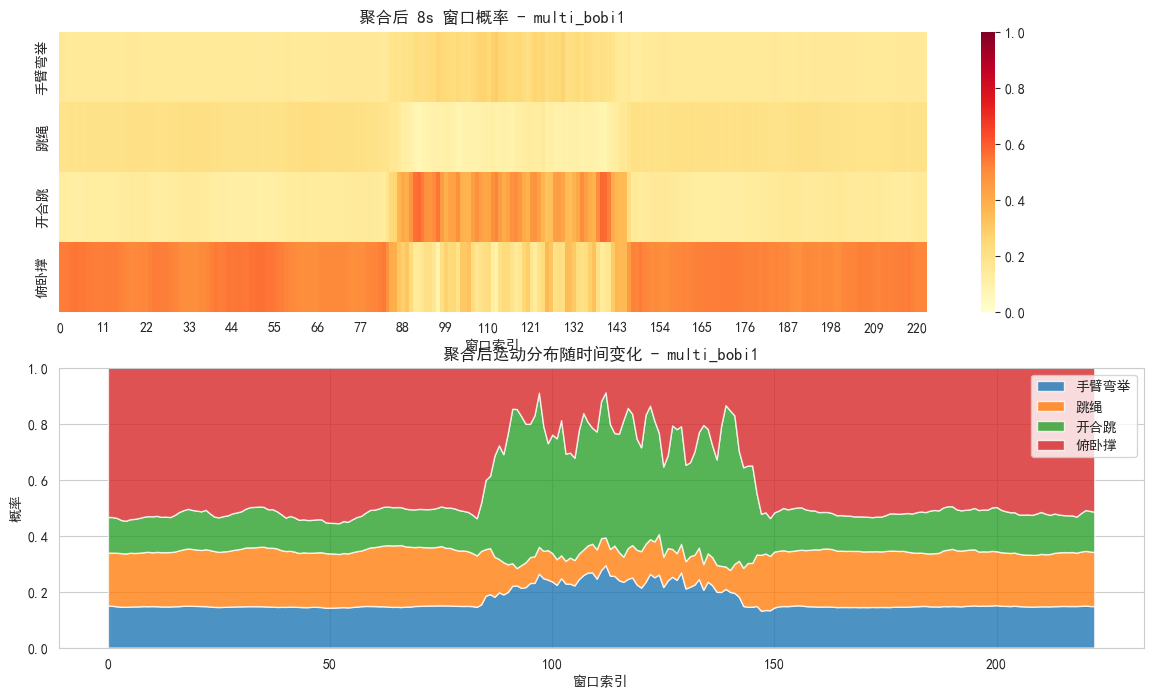

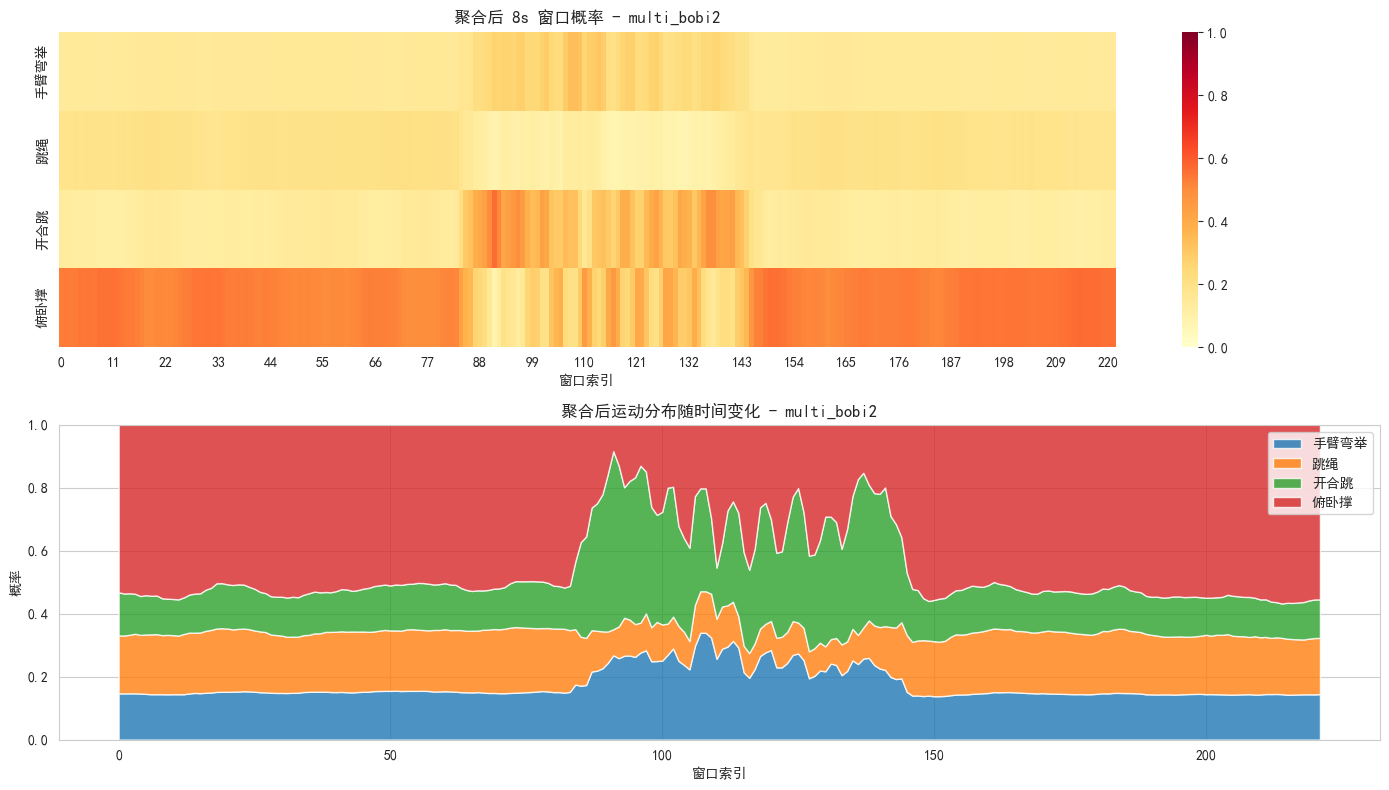

In [7]:
for stem in np.unique(agg_files):
    file_mask = agg_files == stem
    proba_file = agg_proba[file_mask]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1, 1]})

    ax = axes[0]
    sns.heatmap(proba_file.T,
                xticklabels=max(1, len(proba_file) // 20),
                yticklabels=[EXERCISES[c]["label"] for c in SIMPLE_CLASSES],
                cmap="YlOrRd", vmin=0, vmax=1, ax=ax)
    ax.set_xlabel("窗口索引")
    ax.set_title(f"聚合后 8s 窗口概率 - {stem}")

    ax = axes[1]
    ax.stackplot(
        range(len(proba_file)),
        *[proba_file[:, i] for i in range(proba_file.shape[1])],
        labels=[EXERCISES[c]["label"] for c in SIMPLE_CLASSES],
        alpha=0.8,
    )
    ax.set_xlabel("窗口索引")
    ax.set_ylabel("概率")
    ax.set_title(f"聚合后运动分布随时间变化 - {stem}")
    ax.legend(loc="upper right")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# 短窗口级别的细粒度热力图 (未聚合)
for stem in np.unique(burpee_files):
    file_mask = burpee_files == stem
    proba_file = rf_proba[file_mask]

    fig, ax = plt.subplots(figsize=(16, 4))
    sns.heatmap(
        proba_file.T,
        xticklabels=max(1, len(proba_file) // 30),
        yticklabels=[EXERCISES[c]["label"] for c in SIMPLE_CLASSES],
        cmap="YlOrRd", vmin=0, vmax=1, ax=ax,
    )
    ax.set_xlabel("短窗口索引 (2s 窗口)")
    ax.set_title(f"短窗口概率分布 - {stem}")
    plt.tight_layout()
    plt.show()

## 3. 与原版 8s 窗口分类器对比

In [9]:
orig_proba_path = ARTIFACTS_DIR / "burpee_window_distributions.npy"
orig_meta_path = ARTIFACTS_DIR / "burpee_meta.pkl"

if orig_proba_path.exists() and orig_meta_path.exists():
    orig_proba = np.load(orig_proba_path)
    with open(orig_meta_path, "rb") as f:
        orig_meta = pickle.load(f)

    print("=== 原版 8s 窗口 vs 短窗口聚合对比 ===\n")

    for stem in np.unique(agg_files):
        agg_mask = agg_files == stem
        agg_p = agg_proba[agg_mask]
        agg_p_pred = np.array([SIMPLE_CLASSES[i] for i in agg_p.argmax(axis=1)])

        orig_mask = orig_meta["files"] == stem
        orig_p = orig_proba[orig_mask]
        orig_p_pred = np.array([SIMPLE_CLASSES[i] for i in orig_p.argmax(axis=1)])

        print(f"--- {stem} ---")
        print(f"  聚合版窗口: {len(agg_p_pred)}, 原版窗口: {len(orig_p_pred)}")

        cnt_agg = Counter(agg_p_pred)
        cnt_orig = Counter(orig_p_pred)
        print(f"  聚合版: {dict(sorted([(EXERCISES[k]['label'], v) for k, v in cnt_agg.items()]))}")
        print(f"  原版:   {dict(sorted([(EXERCISES[k]['label'], v) for k, v in cnt_orig.items()]))}")
        print(f"  聚合版置信度: mean={agg_p.max(axis=1).mean():.3f}")
        print(f"  原版置信度:   mean={orig_p.max(axis=1).mean():.3f}\n")

    all_agg_pred = np.array([SIMPLE_CLASSES[i] for i in agg_proba.argmax(axis=1)])
    all_orig_pred = np.array([SIMPLE_CLASSES[i] for i in orig_proba.argmax(axis=1)])

    print("=== 总体预测分布对比 ===")
    print("聚合版:")
    for cls, cnt in sorted(Counter(all_agg_pred).items()):
        print(f"  {EXERCISES[cls]['label']}: {cnt} ({cnt/len(all_agg_pred)*100:.1f}%)")
    print("原版:")
    for cls, cnt in sorted(Counter(all_orig_pred).items()):
        print(f"  {EXERCISES[cls]['label']}: {cnt} ({cnt/len(all_orig_pred)*100:.1f}%)")
else:
    print("原版分类结果文件不存在, 跳过对比")

=== 原版 8s 窗口 vs 短窗口聚合对比 ===

--- multi_bobi1 ---
  聚合版窗口: 223, 原版窗口: 217
  聚合版: {'俯卧撑': 169, '开合跳': 54}
  原版:   {'俯卧撑': 158, '开合跳': 59}
  聚合版置信度: mean=0.496
  原版置信度:   mean=0.685

--- multi_bobi2 ---
  聚合版窗口: 222, 原版窗口: 218
  聚合版: {'俯卧撑': 179, '开合跳': 40, '手臂弯举': 3}
  原版:   {'俯卧撑': 160, '开合跳': 55, '手臂弯举': 3}
  聚合版置信度: mean=0.493
  原版置信度:   mean=0.684

=== 总体预测分布对比 ===
聚合版:
  手臂弯举: 3 (0.7%)
  开合跳: 94 (21.1%)
  俯卧撑: 348 (78.2%)
原版:
  手臂弯举: 3 (0.7%)
  开合跳: 114 (26.2%)
  俯卧撑: 318 (73.1%)


In [ ]:
import joblib

np.save(ARTIFACTS_DIR / "burpee_window_distributions_shortwin.npy", agg_proba)
joblib.dump({"model": rf, "scaler": scaler, "label_encoder": le},
            ARTIFACTS_DIR / "classifier_model_shortwin.pkl")

burpee_meta = {
    "times": agg_times,
    "files": agg_files,
    "class_names": SIMPLE_CLASSES,
    "short_win_proba": rf_proba,
    "short_win_times": burpee_times,
    "short_win_files": burpee_files,
}
with open(ARTIFACTS_DIR / "burpee_meta_shortwin.pkl", "wb") as f:
    pickle.dump(burpee_meta, f)

print("已保存:")
print(f"  burpee_window_distributions_shortwin.npy: shape={agg_proba.shape}")
print(f"  classifier_model_shortwin.pkl")
print(f"  burpee_meta_shortwin.pkl (含短窗口级原始数据)")